In [92]:
# 🔧 DIAGNÓSTICO DE ERRO CUDA - Execute antes de treinar
import torch
import torch.cuda as cuda

print("="*80)
print("📊 DIAGNÓSTICO DO SISTEMA GPU")
print("="*80)

# Verificar GPU
print(f"CUDA disponível: {torch.cuda.is_available()}")
print(f"GPU encontrada: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'Nenhuma'}")

if torch.cuda.is_available():
    # Limpar cache antes de começar
    print("\n🧹 Limpando cache de GPU...")
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    # Informações de memória
    props = torch.cuda.get_device_properties(0)
    total_memory = props.total_memory / 1e9
    print(f"Memória total da GPU: {total_memory:.2f} GB")

    allocated = torch.cuda.memory_allocated() / 1e9
    reserved = torch.cuda.memory_reserved() / 1e9
    print(f"Memória alocada: {allocated:.2f} GB")
    print(f"Memória reservada: {reserved:.2f} GB")
    print(f"Memória livre: {(total_memory - reserved):.2f} GB")

    # Verificar compatibilidade
    print(f"\nVersão CUDA: {torch.version.cuda}")
    print(f"Versão cuDNN: {torch.backends.cudnn.version()}")
    print(f"cuDNN habilitado: {torch.backends.cudnn.enabled}")

else:
    print("⚠️  CUDA não disponível! Usando CPU (muito lento).")

print("="*80 + "\n")

📊 DIAGNÓSTICO DO SISTEMA GPU
CUDA disponível: True
GPU encontrada: Tesla T4

🧹 Limpando cache de GPU...
Memória total da GPU: 15.64 GB
Memória alocada: 1.20 GB
Memória reservada: 5.19 GB
Memória livre: 10.45 GB

Versão CUDA: 12.8
Versão cuDNN: 91900
cuDNN habilitado: True



In [93]:
import pandas as pd
from PIL import Image, ImageChops
import numpy as np
import torch
from sklearn.model_selection import KFold
from torch.utils.data import  DataLoader, TensorDataset, Dataset
from torch import nn
import timm
from tqdm.notebook import tqdm
import torch.optim as optim
import os

In [94]:
print()

## Load and copy dataset to content on Drive or Local

In [95]:

import time
ts = int(time.time())
timestamp = str(ts)
from datetime import datetime

if os.getenv("IS_LOCAL"):
    FILE_PATH = 'dataset_FA_OUTROS_NORMAL_BINARY_HOT_ENCODING.csv'

    print("Iniciando o programa em execucao Local")
    print("Parametros de Execucao Local:")
    folds = 5
    epochs = 50
    BATCH_SIZE = 8 # ✅ REDUZIDO de 64 para 32 (evita erro CUDA)
    N_samples = None  # Use None para usar todos os dados
    flg_salvar_modelos = True
    path = '/home/leo/Documents/ecg_classifier/dataset/database_ptbxl/'
    path_out = 'saida_123/saidas/'
    OUTPUT_TEST_PATH = 'OUTPUTTESTES/'
    OUTPUT_MODEL_PATH = 'OUTPUTMODELS/'

    print(f"  Numero de folds para K-Fold Cross Validation: {folds}")

    print(f"  Tamanho do batch para treinamento: {BATCH_SIZE}")

    print(f"  Numero de epocas para treinamento: {epochs}")
else:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    folds = 5
    epochs = 5
    BATCH_SIZE = 64 # ✅ REDUZIDO de 64 para 32 (evita erro CUDA)
    N_samples = 1000  # Use None para usar todos os dados
    flg_salvar_modelos = True
    os.system('cp  "/content/drive/MyDrive/dataset_AFIB_Others/database_ptbxl.zip" "/content/dataset.zip"')
    os.system('unzip -oq dataset.zip')
    FILE_PATH = '/content/drive/MyDrive/dataset_AFIB_Others/dataset_FA_OUTROS_NORMAL_BINARY_HOT_ENCODING.csv'
    path = '/content/content/drive/MyDrive/dataset_AFIB_Others/database_ptbxl/'
    path_out = f'/content/drive/MyDrive/dataset_AFIB_Others/saida_{timestamp}/saidas/'
    OUTPUT_TEST_PATH = f'/content/drive/MyDrive/dataset_AFIB_Others/OUTPUTTESTES/'
    OUTPUT_MODEL_PATH = f'/content/drive/MyDrive/dataset_AFIB_Others/OUTPUTMODELS/'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [96]:
data = pd.read_csv(FILE_PATH)
tensor_label = data[['NORMAL','Other','AFIB']][0:N_samples]
tensor_label.value_counts()
data['NORMAL'].isna().sum()

np.int64(0)

## Load dataset Local

## Filtro de Imagem

In [97]:
from PIL import Image, ImageChops
import numpy as np
import os
import shutil
import io
from pathlib import Path
def treat_image_PIL(img_path, type_return=2):
    ''''
    Input: Img_path, type return.

    Img_path: path da imagem em formato png, img...
    type_return: 1-> retorno como PIL.
                2 ou sem type_return -> retorno como numpy array tipo uint8

    Output:
    '''
    im = Image.open(path+img_path)

    # Size of the image in pixels (size of original image)
    # (This is not mandatory)
    width, height = im.size

    rgb =Image.Image.split(im)

    data =rgb
    b= data[0]
    g= data[1]
    r= data[2]
    #img_out = b+g+.5*r
    #img_out_2 = img_out[500:1600, 50:2100]

    newsize = (256, 256)
   # im3 =ImageChops.subtract(mask,b, scale=1.0, offset=0)

    b1 = b.crop((120,500,2100,1600))
    g1 = g.crop((120,500,2100,1600))
    r1 = r.crop((120,500,2100,1600))
    im1 = b1.resize(newsize, Image.Resampling.LANCZOS).convert('L')
    im2 = g1.resize(newsize, Image.Resampling.LANCZOS).convert('L')
    im3 = r1.resize(newsize, Image.Resampling.LANCZOS).convert('L')
    if type_return ==1:
        return Image.merge("RGB",(im1,im1,im1))
    elif type_return ==2:

        return np.array([im1,im1,im1],dtype=np.uint8)
    elif type_return ==3:

        return np.array([im1,im2,im3],dtype=np.uint8)
    elif type_return ==4:

        return np.array(im3,dtype=np.uint8)

def save_file_to_dir(file_obj, directory, filename):
    """
    Save a file to `directory` with the given `filename`.

    Parameters
    - file_obj: a PIL Image, a filesystem path (str or Path) to an existing file,
                bytes/bytearray, or a file-like object with a .read() method.
    - directory: target directory where the file will be saved.
    - filename: the name to use for the saved file (including extension if desired).

    Returns
    - full path (str) to the saved file.

    Raises
    - FileNotFoundError if a provided source path does not exist.
    - ValueError if the provided file_obj type is unsupported.
    """
    os.makedirs(directory, exist_ok=True)
    dest = os.path.join(directory, filename)

    # PIL Image
    if isinstance(file_obj, Image.Image):
        file_obj.save(dest)
        return dest

    # Path-like or string pointing to an existing file
    if isinstance(file_obj, (str, Path)):
        src = str(file_obj)
        if os.path.exists(src):
            shutil.copy(src, dest)
            return dest
        raise FileNotFoundError(f"Source path not found: {src}")

    # File-like object
    if hasattr(file_obj, "read"):
        data = file_obj.read()
        # If read() returned bytes -> try open as image, otherwise write raw
        if isinstance(data, (bytes, bytearray)):
            try:
                img = Image.open(io.BytesIO(data))
                img.save(dest)
                return dest
            except Exception:
                with open(dest, "wb") as f:
                    f.write(data)
                return dest
        else:
            # assume text
            with open(dest, "w", encoding="utf-8") as f:
                f.write(data)
            return dest

    # Raw bytes
    if isinstance(file_obj, (bytes, bytearray)):
        try:
            img = Image.open(io.BytesIO(file_obj))
            img.save(dest)
            return dest
        except Exception:
            with open(dest, "wb") as f:
                f.write(file_obj)
            return dest

    raise ValueError("file_obj must be a PIL.Image, path string/Path, bytes or file-like object")

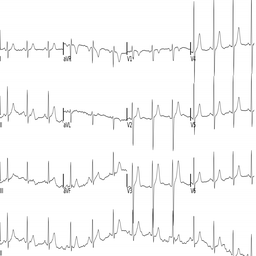

(3, 256, 256)
uint8


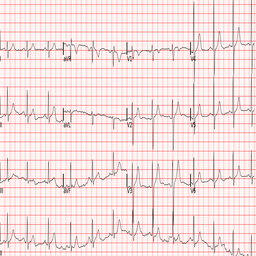

In [98]:
## Exemplo de uso de resize de imagem
image  = treat_image_PIL('00004_lr-0.png',1)
display(image)

## treat image pil as array and return to Image PIL and display
img_array = treat_image_PIL('00004_lr-0.png',3)
print(img_array.shape)
print(img_array.dtype)
img_pil = Image.fromarray(img_array.transpose(1, 2, 0))  # (3, 256, 256) → (256, 256, 3)
display(img_pil)

In [99]:
import os
## Cria funcao para validar se pasta a ser inserida existe. Caso nao exista, cria a pasta
def create_folder_if_not_exists(folder_path):
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)
        print(f'Pasta {folder_path} criada.')
    else:
        print(f'Pasta {folder_path} ja existe.')


In [100]:
from torch.utils.data import  Dataset

class Subset(Dataset):
    r"""
    Subset of a dataset at specified indices.

    Arguments:
        dataset (Dataset): The whole Dataset
        indices (sequence): Indices in the whole set selected for subset
    """
    def __init__(self, dataset, indices):
        self.dataset = dataset
        self.indices = indices

    def __getitem__(self, idx):
        return self.dataset[self.indices[idx]]

    def __len__(self):
        return len(self.indices)

    @property
    def classes(self):
        return self.data.classes

    def shape(self):
        return self.dataset

## Loop de Treinamento e Validacao

In [101]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device: " + str(device))

Device: cuda:0


In [102]:
import torch
from torch import nn
import numpy as np
import os
import matplotlib.pyplot as plt
import torch.optim as optim
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, precision_recall_fscore_support
from torch.cuda.amp import autocast, GradScaler
from torch.optim.lr_scheduler import ReduceLROnPlateau

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device: " + str(device))

def salvar_model(model, path = '/content/drive/MyDrive/4000-files/output/modelos', name_file='model.pth'):
    create_folder_if_not_exists(path)

    full_path = os.path.join(path, name_file)
    torch.save(model.state_dict(), full_path)

def salvar_metricas(path, name_file_train='train_loss_total.npy', name_file_val='val_loss_total.npy',predict_label=None, true_label=None):
    create_folder_if_not_exists(path)
    full_path_train = os.path.join(path, name_file_train)
    full_path_val = os.path.join(path, name_file_val)
    np.save(full_path_train, np.array(predict_label))
    np.save(full_path_val, np.array(true_label))
    print(f'Metricas salvas em {path} com os nomes {name_file_train} e {name_file_val} e tamanhos {np.array(predict_label).shape} e {np.array(true_label).shape}')

def salvar_readme_execucao(path, metadata):
    create_folder_if_not_exists(path)
    readme_path = os.path.join(path, 'readme.md')
    lines = [
        '# Execucao do Treinamento\n',
        '\n',
        'Este diretório concentra as métricas e os artefatos de uma execução do treino.\n',
        '\n',
        '## Identificacao\n',
        f"- data_hora: {metadata.get('data_hora', 'n/a')}\n",
        f"- notebook: {metadata.get('notebook', 'n/a')}\n",
        f"- execucao_id: {metadata.get('execucao_id', 'n/a')}\n",
        f"- fold_index: {metadata.get('fold_index', 'n/a')}\n",
        f"- output_root: {metadata.get('output_root', 'n/a')}\n",
        '\n',
        '## Dataset\n',
        f"- csv_path: {metadata.get('csv_path', 'n/a')}\n",
        f"- image_root: {metadata.get('image_root', 'n/a')}\n",
        f"- n_amostras_total: {metadata.get('n_amostras_total', 'n/a')}\n",
        f"- n_train: {metadata.get('n_train', 'n/a')}\n",
        f"- n_val: {metadata.get('n_val', 'n/a')}\n",
        f"- split_by_patient_id: {metadata.get('split_by_patient_id', True)}\n",
        f"- train_patient_ids: {metadata.get('train_patient_ids', 'n/a')}\n",
        f"- val_patient_ids: {metadata.get('val_patient_ids', 'n/a')}\n",
        '\n',
        '## Treinamento\n',
        f"- model_name: {metadata.get('model_name', 'n/a')}\n",
        f"- epochs: {metadata.get('epochs', 'n/a')}\n",
        f"- batch_size: {metadata.get('batch_size', 'n/a')}\n",
        f"- learning_rate: {metadata.get('learning_rate', 'n/a')}\n",
        f"- weight_decay: {metadata.get('weight_decay', 'n/a')}\n",
        f"- label_smoothing: {metadata.get('label_smoothing', 'n/a')}\n",
        f"- l2_lambda: {metadata.get('l2_lambda', 'n/a')}\n",
        f"- patience: {metadata.get('patience', 'n/a')}\n",
        f"- delta: {metadata.get('delta', 'n/a')}\n",
        f"- scheduler: {metadata.get('scheduler', 'n/a')}\n",
        f"- class_weights: {metadata.get('class_weights', 'n/a')}\n",
        f"- freeze_epochs: {metadata.get('freeze_epochs', 'n/a')}\n",
        f"- unfreeze_last_n_blocks: {metadata.get('unfreeze_last_n_blocks', 'n/a')}\n",
        '\n',
        '## Augmentation\n',
        f"- multiplier_dataaug: {metadata.get('multiplier_dataaug', 'n/a')}\n",
        f"- aug_version: {metadata.get('aug_version', 'n/a')}\n",
        f"- transform_summary: {metadata.get('transform_summary', 'n/a')}\n",
        '\n',
        '## Resultados\n',
        f"- metricas_valid_dir: {metadata.get('metricas_valid_dir', 'n/a')}\n",
        f"- metricas_train_dir: {metadata.get('metricas_train_dir', 'n/a')}\n",
        f"- class_metrics_dir: {metadata.get('class_metrics_dir', 'n/a')}\n",
    ]
    with open(readme_path, 'w', encoding='utf-8') as f:
        f.writelines(lines)
    print(f'Readme de execucao salvo em {readme_path}')

def salvar_log_treinamento(path, log_lines):
    create_folder_if_not_exists(path)
    log_path = os.path.join(path, 'training_log.txt')
    with open(log_path, 'w', encoding='utf-8') as f:
        f.write('\n'.join(log_lines) + '\n')
    print(f'Log de treinamento salvo em {log_path}')

def salvar_metricas_por_classe(path, fold_index, class_names, train_history, val_history):
    create_folder_if_not_exists(path)
    for metric_name, train_arr, val_arr in [
        ('precision', train_history['precision'], val_history['precision']),
        ('recall', train_history['recall'], val_history['recall']),
        ('f1', train_history['f1'], val_history['f1']),
    ]:
        np.save(os.path.join(path, f'train_{metric_name}_per_class_fold_{fold_index}.npy'), np.array(train_arr))
        np.save(os.path.join(path, f'val_{metric_name}_per_class_fold_{fold_index}.npy'), np.array(val_arr))

def plotar_metricas_por_classe(path, fold_index, class_names, train_history, val_history):
    epochs = np.arange(1, len(train_history['precision']) + 1)
    fig, axes = plt.subplots(3, 1, figsize=(12, 14), sharex=True)
    metrics = [('precision', 'Precision'), ('recall', 'Recall'), ('f1', 'F1')]
    for ax, (metric_key, metric_label) in zip(axes, metrics):
        train_arr = np.asarray(train_history[metric_key])
        val_arr = np.asarray(val_history[metric_key])
        for idx, class_name in enumerate(class_names):
            ax.plot(epochs, train_arr[:, idx], linestyle='--', label=f'Train {class_name}')
            ax.plot(epochs, val_arr[:, idx], linestyle='-', label=f'Val {class_name}')
        ax.set_title(f'Fold {fold_index} - {metric_label} por classe')
        ax.set_ylabel(metric_label)
        ax.grid(True, alpha=0.3)
        ax.legend(ncol=3, fontsize=8)
    axes[-1].set_xlabel('Epoch')
    plt.tight_layout()
    create_folder_if_not_exists(path)
    fig.savefig(os.path.join(path, f'class_metrics_fold_{fold_index}.png'), dpi=150, bbox_inches='tight')
    plt.close(fig)

def simple_loop(model, train_image, val_image, epochs, batch_size, fold_index, patience=10, delta=0.0001, device_input=None, l2_lambda=1e-4, class_weights=None):
    """
    Loop de treinamento e validação com Early Stopping, regularização L2 explícita e monitoramento de métricas.
    """
    if device_input is None:
        device_input = device

    num_epochs = epochs
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []
    train_f1s, val_f1s = [], []
    train_class_history = {'precision': [], 'recall': [], 'f1': []}
    val_class_history = {'precision': [], 'recall': [], 'f1': []}
    class_names = ['NORMAL', 'Other', 'AFIB']
    class_labels = [0, 1, 2]
    iter_size = batch_size
    print(f'Number of training images per iteration: {iter_size}')
    print(f'Device sendo usado: {device_input}')
    print(f'Penalidade L2 aplicada: {l2_lambda}')

    try:
        model = model.to(device_input)
        print(f'✓ Modelo movido para {device_input}')
    except Exception as e:
        print(f'❌ ERRO ao mover modelo para device: {e}')
        raise

    criterion = nn.CrossEntropyLoss(
        weight=class_weights.to(device_input) if class_weights is not None else None,
        label_smoothing=0.05
    )
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=1e-4,
        weight_decay=1e-4
    )

    scheduler = ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3,
        threshold=1e-4,
        cooldown=1,
        min_lr=1e-7
    )
    predict_label_full_train = []
    predict_label_full = []
    true_label_full_train = []
    true_label_full = []
    training_log_lines = []

    for epoch in range(num_epochs):
        model.train()
        predict_label_train = []
        true_label_train = []
        running_loss_train = 0.0

        try:
            for images, labels in tqdm(train_image, desc='Training loop'):
                images = images.to(device_input)
                labels = labels.to(device_input)
                images = images.to(torch.float32)
                labels = labels.to(torch.float32)
                optimizer.zero_grad()

                outputs = model(images)

                pred_train = torch.argmax(outputs, dim=1)
                _true = torch.argmax(labels, dim=1)

                loss_train = criterion(outputs, labels)
                loss_train.backward()

                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                _pred_train = torch.argmax(outputs, dim=1)
                running_loss_train += loss_train.item() * labels.size(0)

                try:
                    pred_list = _pred_train.cpu().numpy().astype(int).tolist()
                    true_list = _true.cpu().numpy().astype(int).tolist()

                    if not isinstance(pred_list, list):
                        pred_list = [pred_list]
                    if not isinstance(true_list, list):
                        true_list = [true_list]

                    if len(pred_list) == iter_size:
                        predict_label_train.append(pred_list)
                        true_label_train.append(true_list)

                except Exception as e:
                    print(f"⚠ Erro ao salvar predições de treinamento: {e}")

        except RuntimeError as e:
            if "CUDA" in str(e) or "assert" in str(e).lower():
                print(f"\n❌ ERRO CUDA durante treinamento: {e}")
                print("💡 Sugestões:")
                print("   1. Reduza BATCH_SIZE")
                print("   2. Execute torch.cuda.empty_cache()")
                print("   3. Use modelos menores")
                torch.cuda.empty_cache()
                raise
            else:
                raise

        train_loss = running_loss_train / len(train_image.dataset)
        train_losses.append(train_loss)

        train_precision_c = train_recall_c = train_f1_c = None
        try:
            if predict_label_train and true_label_train:
                train_preds = np.concatenate(predict_label_train)
                train_trues = np.concatenate(true_label_train)
                train_acc = accuracy_score(train_trues, train_preds)
                train_f1 = f1_score(train_trues, train_preds, average='weighted', zero_division=0)
                train_precision_c, train_recall_c, train_f1_c, _ = precision_recall_fscore_support(
                    train_trues,
                    train_preds,
                    labels=class_labels,
                    zero_division=0,
                )
                train_accuracies.append(train_acc)
                train_f1s.append(train_f1)
                train_class_history['precision'].append(train_precision_c)
                train_class_history['recall'].append(train_recall_c)
                train_class_history['f1'].append(train_f1_c)
        except Exception as e:
            print(f"⚠ Erro ao calcular métricas de treinamento: {e}")
            print(f"  predict_label_train: {train_preds}")
            print(f"  true_label_train: {train_trues}")
        try:
            _p_train = predict_label_train
            _t_train = true_label_train
            predict_label_full_train.append(_p_train)
            true_label_full_train.append(_t_train)
        except Exception as e:
            print(f"⚠ Erro ao concatenar métricas de treinamento: {e}")
            print(f"  predict_label_train: {train_preds}")
            print(f"  true_label_train: {train_trues}")

        model.eval()
        running_loss_valid = 0.0
        predict_label = []
        true_label = []
        _iter = 0

        try:
            with torch.no_grad():
                for images, labels in tqdm(val_image, desc='Validation loop'):
                    images = images.to(device_input)
                    labels = labels.to(device_input)
                    images = images.to(torch.float32)
                    labels = labels.to(torch.float32)

                    outputs = model(images)
                    pred_out = torch.argmax(outputs, dim=1)
                    true_out = torch.argmax(labels, dim=1)

                    loss_valid = criterion(outputs, labels)

                    try:
                        pred_list = pred_out.cpu().numpy().astype(int).tolist()
                        true_list = true_out.cpu().numpy().astype(int).tolist()

                        if not isinstance(pred_list, list):
                            pred_list = [pred_list]
                        if not isinstance(true_list, list):
                            true_list = [true_list]

                        if len(pred_list) == iter_size:
                            predict_label.append(pred_list)
                            true_label.append(true_list)

                    except Exception as e:
                        print(f"⚠ Erro ao salvar predições de validação: {e}")

                    running_loss_valid += loss_valid.item() * labels.size(0)
                    _iter += 1

        except RuntimeError as e:
            if "CUDA" in str(e) or "assert" in str(e).lower():
                print(f"\n❌ ERRO CUDA durante validação: {e}")
                torch.cuda.empty_cache()
                raise
            else:
                raise

        val_loss = running_loss_valid / len(val_image.dataset)
        val_losses.append(val_loss)
        scheduler.step(val_loss)

        val_precision = 0
        val_recall = 0
        val_precision_c = val_recall_c = val_f1_c = None
        try:
            if predict_label and true_label:
                val_preds = np.concatenate(predict_label)
                val_trues = np.concatenate(true_label)
                val_acc = accuracy_score(val_trues, val_preds)
                val_f1 = f1_score(val_trues, val_preds, average='weighted', zero_division=0)
                val_precision = precision_score(val_trues, val_preds, average='weighted', zero_division=0)
                val_recall = recall_score(val_trues, val_preds, average='weighted', zero_division=0)
                val_precision_c, val_recall_c, val_f1_c, _ = precision_recall_fscore_support(
                    val_trues,
                    val_preds,
                    labels=class_labels,
                    zero_division=0,
                )
                val_accuracies.append(val_acc)
                val_f1s.append(val_f1)
                val_class_history['precision'].append(val_precision_c)
                val_class_history['recall'].append(val_recall_c)
                val_class_history['f1'].append(val_f1_c)
        except Exception as e:
            print(f"⚠ Erro ao calcular métricas de validação: {e}")

        try:
            _p = predict_label
            _t = true_label
            predict_label_full.append(_p)
            true_label_full.append(_t)
        except Exception as e:
            print(f"⚠ Erro ao concatenar métricas de validação: {e}")

        print(f"\n{'='*80}")
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"{'='*80}")
        print(f"Train Loss: {train_loss:.6f}", end="")
        if train_accuracies:
            print(f" | Train Acc: {train_accuracies[-1]:.4f}", end="")
            print(f" | Train F1: {train_f1s[-1]:.4f}", end="")

        print()
        print(f"Val Loss:   {val_loss:.6f}", end="")
        if val_accuracies:
            print(f" | Val Acc: {val_accuracies[-1]:.4f}", end="")
            print(f" | Val F1: {val_f1s[-1]:.4f}", end="")
            print(f" | Precision: {val_precision:.4f}", end="")
            print(f" | Recall: {val_recall:.4f}", end="")
        print()
        log_line = (
            f"Epoch {epoch+1}/{num_epochs} | TrainLoss={train_loss:.6f} | "
            f"TrainAcc={(train_accuracies[-1] if train_accuracies else float('nan')):.4f} | "
            f"TrainF1={(train_f1s[-1] if train_f1s else float('nan')):.4f} | "
            f"ValLoss={val_loss:.6f} | ValAcc={(val_accuracies[-1] if val_accuracies else float('nan')):.4f} | "
            f"ValF1={(val_f1s[-1] if val_f1s else float('nan')):.4f} | ValPrecision={val_precision:.4f} | ValRecall={val_recall:.4f}"
        )
        if train_precision_c is not None and val_precision_c is not None:
            train_class_str = ' ; '.join(
                f"{name}:P={train_precision_c[idx]:.4f},R={train_recall_c[idx]:.4f},F1={train_f1_c[idx]:.4f}"
                for idx, name in enumerate(class_names)
            )
            val_class_str = ' ; '.join(
                f"{name}:P={val_precision_c[idx]:.4f},R={val_recall_c[idx]:.4f},F1={val_f1_c[idx]:.4f}"
                for idx, name in enumerate(class_names)
            )
            log_line += f" | TrainClass=[{train_class_str}] | ValClass=[{val_class_str}]"
        training_log_lines.append(log_line)
        if train_precision_c is not None and val_precision_c is not None:
            print('Train por classe:')
            for idx, name in enumerate(class_names):
                print(
                    f"  {name}: P={train_precision_c[idx]:.4f} | R={train_recall_c[idx]:.4f} | F1={train_f1_c[idx]:.4f}"
                )
            print('Val por classe:')
            for idx, name in enumerate(class_names):
                print(
                    f"  {name}: P={val_precision_c[idx]:.4f} | R={val_recall_c[idx]:.4f} | F1={val_f1_c[idx]:.4f}"
                )
        print(f"{'='*80}\n")

    predict_label_full_out = np.array(predict_label_full, dtype=object)
    true_label_full_out = np.array(true_label_full, dtype=object)
    predict_label_full_train_out = np.array(predict_label_full_train, dtype=object)
    true_label_full_train_out = np.array(true_label_full_train, dtype=object)
    print(f'Salvado das metricas de validacao e treino')

    salvar_metricas(path=f'{path_out}/output/metricas/valid/fold_{fold_index}',
                    name_file_train=f'predict_label_valid_fold_{fold_index}.npy',
                    name_file_val=f'true_label_valid_fold_{fold_index}.npy',
                    predict_label= predict_label_full_out, true_label= true_label_full_out)

    salvar_metricas(path=f'{path_out}/output/metricas/train/fold_{fold_index}',
                    name_file_train=f'predict_label_train_fold_{fold_index}.npy',
                    name_file_val=f'true_label_train_fold_{fold_index}.npy',
                    predict_label= predict_label_full_train_out, true_label= true_label_full_train_out)
    salvar_readme_execucao(
        path=f'{path_out}/output',
        metadata={
            'data_hora': datetime.now().isoformat(timespec='seconds'),
            'notebook': 'AFIB_OUTROS_NORMAL_DATAAUG_regularizado_v2.ipynb',
            'execucao_id': os.path.basename(path_out),
            'fold_index': fold_index,
            'output_root': path_out,
            'csv_path': csv_path if 'csv_path' in globals() else 'n/a',
            'image_root': path,
            'n_amostras_total': len(data) if 'data' in globals() else 'n/a',
            'n_train': len(dados_train),
            'n_val': len(dados_val),
            'split_by_patient_id': True,
            'train_patient_ids': sorted(train_patient_ids.tolist()) if 'train_patient_ids' in globals() else 'n/a',
            'val_patient_ids': sorted(val_patient_ids.tolist()) if 'val_patient_ids' in globals() else 'n/a',
            'model_name': model.__class__.__name__,
            'epochs': epochs,
            'batch_size': BATCH_SIZE,
            'learning_rate': 1e-4,
            'weight_decay': 1e-4,
            'label_smoothing': 0.05,
            'l2_lambda': 1e-4,
            'patience': 5,
            'delta': 0.0001,
            'scheduler': 'ReduceLROnPlateau(factor=0.5, patience=3, cooldown=1, min_lr=1e-7)',
            'class_weights': class_weights.detach().cpu().tolist() if class_weights is not None else 'n/a',
            'freeze_epochs': 'n/a',
            'unfreeze_last_n_blocks': 'n/a',
            'multiplier_dataaug': multiplier_dataaug if 'multiplier_dataaug' in globals() else 'n/a',
            'aug_version': 3,
            'transform_summary': 'transform3 conservadora+ para ECG',
            'metricas_valid_dir': f'{path_out}/output/metricas/valid/fold_{fold_index}',
            'metricas_train_dir': f'{path_out}/output/metricas/train/fold_{fold_index}',
            'class_metrics_dir': f'{path_out}/output/metricas/class_metrics/fold_{fold_index}',
        }
    )
    salvar_log_treinamento(
        path=f'{path_out}/output',
        log_lines=[
            f'notebook=AFIB_OUTROS_NORMAL_DATAAUG_regularizado.ipynb',
            f'execucao_id={os.path.basename(path_out)}',
            f'fold_index={fold_index}',
            f'epochs=30',
            f'batch_size={BATCH_SIZE}',
            f'aug_version=3',
            f'multiplier_dataaug={multiplier_dataaug if "multiplier_dataaug" in globals() else "n/a"}',
            '---',
            *training_log_lines,
        ]
    )
    salvar_metricas_por_classe(
        path=f'{path_out}/output/metricas/class_metrics/fold_{fold_index}',
        fold_index=fold_index,
        class_names=class_names,
        train_history=train_class_history,
        val_history=val_class_history,
    )
    plotar_metricas_por_classe(
        path=f'{path_out}/output/metricas/class_metrics/fold_{fold_index}',
        fold_index=fold_index,
        class_names=class_names,
        train_history=train_class_history,
        val_history=val_class_history,
    )
    print(f'Finalizado o salvamento das metricas')
    return train_losses, val_losses, model, predict_label_full_out, true_label_full_out

Device: cuda:0


## Versao Regularizada v2

Esta copia endurece a regularizacao, mantem augmentation conservadora e limita o treino a 30 epocas para reduzir overfitting.


## Modelos de Classificacao

In [103]:
#from models import ECGClassifierResnet
from torch import nn
import timm
class ECGClassifierResnet(nn.Module):
    def __init__(self, num_classes=1):
        super(ECGClassifierResnet, self).__init__()
        # Where we define all the parts of the model
        #self.base_model = timm.create_model('efficientnet_b0', pretrained=True)
        self.base_model=timm.create_model('resnet50d.ra4_e3600_r224_in1k',pretrained=True)
        #self.base_model = timm.create_model('vit_mediumd_patch16_reg4_gap_256.sbb2_e200_in12k_ft_in1k',num_classes=5,pretrained=True)

        self.features = nn.Sequential(*list(self.base_model.children())[:-1])

        enet_out_size = 2048        # Make a classifier
        # For binary classification com Dropout para regularização
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),            # Regularizacao um pouco mais forte para conter overfitting
            nn.ReLU(),
            nn.Dropout(0.3),            # Regularizacao adicional
            nn.Linear(enet_out_size, 3)
        ) # saida como Softmax para classificacao single label

    def forward(self, x):
        # Connect these parts and return the output
        #converte 1 canal para 3 canais (RGB) usando uma camada Conv2d
        #x1 = nn.Conv2d(3, 1, kernel_size=3, stride=1, padding=1)(x)  # Converte de 1 canal para 3 canais
        x = self.features(x)
        output = self.classifier(x)
        #output = nn.Softmax(dim=1)(output)
        return output


In [104]:
#from models import ECGClassifierResnet
from torch import nn
import timm
class ECGClassifierMambaVision(nn.Module):
    def __init__(self, num_classes=1):
        super(ECGClassifierMambaVision, self).__init__()
        # Where we define all the parts of the model
        #self.base_model = timm.create_model('efficientnet_b0', pretrained=True)
        self.base_model=timm.create_model('mamba_vision_L2',pretrained=True)
        #self.base_model = timm.create_model('vit_mediumd_patch16_reg4_gap_256.sbb2_e200_in12k_ft_in1k',num_classes=5,pretrained=True)

        self.features = nn.Sequential(*list(self.base_model.children())[:-1])

        enet_out_size = 2048        # Make a classifier
        # For binary classification com Dropout para regularização
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.7),           # Dropout para regularização (reduz overfitting)
            nn.ReLU(),
            nn.Dropout(0.5),           # Dropout adicional antes da saída
            nn.Linear(enet_out_size, 2)
        ) # saida como Softmax para classificacao single label

    def forward(self, x):
        # Connect these parts and return the output
        #converte 1 canal para 3 canais (RGB) usando uma camada Conv2d
        #x1 = nn.Conv2d(3, 1, kernel_size=3, stride=1, padding=1)(x)  # Converte de 1 canal para 3 canais
        x = self.features(x)
        output = self.classifier(x)
        #output = nn.Softmax(dim=1)(output)
        return output




In [105]:
class ECGClassifierEfficientNet(nn.Module):
    def __init__(self, num_classes=1):
        super(ECGClassifierEfficientNet, self).__init__()
        # Where we define all the parts of the model
        self.base_model = timm.create_model('efficientnet_b0', pretrained=True)
        self.features = nn.Sequential(*list(self.base_model.children())[:-1])

        enet_out_size = 1280  # Saída do EfficientNet-B0
        # For binary classification com Dropout para regularização
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.7),  # Dropout para regularização (reduz overfitting)
            nn.ReLU(),
            nn.Dropout(0.5),  # Dropout adicional antes da saída
            nn.Linear(enet_out_size, 3)  # Saída para 3 classes
        )

    def forward(self, x):
        x = self.features(x)
        output = self.classifier(x)
        return output

## Exploracao CSV

In [106]:
## Funções Otimizadas para Leitura de CSV e Carregamento de Imagens

import os
import psutil
from pathlib import Path

def explore_csv(csv_path, max_rows=5):
    """
    Explora arquivo CSV fornecendo informações detalhadas.

    Parâmetros:
        csv_path (str): Caminho do arquivo CSV
        max_rows (int): Número de linhas para exibir

    Retorna:
        pd.DataFrame: Dados carregados
    """
    print("="*80)
    print("📋 EXPLORAÇÃO DO ARQUIVO CSV")
    print("="*80)

    # Verificar se arquivo existe
    if not os.path.exists(csv_path):
        print(f"❌ ERRO: Arquivo não encontrado: {csv_path}")
        return None

    print(f"✓ Arquivo encontrado: {csv_path}")
    print(f"  Tamanho do arquivo: {os.path.getsize(csv_path) / (1024*1024):.2f} MB")

    ## rename 0 col to path , 1 col to label and 2 col to patient id if exists
    # map col label to AFIB =1 and Others = 0

    try:
        # Ler CSV
        print("\n📖 Lendo arquivo CSV...")
        data = pd.read_csv(csv_path)

        print(f"✓ CSV lido com sucesso!")
        print(f"  Shape: {data.shape} (linhas, colunas)")
        print(f"  Colunas: {list(data.columns)}")
        print(f"  Tipos de dados:\n{data.dtypes}\n")

        # Verificar valores nulos
        print("📊 Valores Nulos:")
        null_counts = data.isnull().sum()
        if null_counts.sum() == 0:
            print("  ✓ Nenhum valor nulo encontrado!")
        else:
            print(f"  ⚠ Valores nulos encontrados:\n{null_counts}\n")

        # Primeiras linhas
        print(f"📄 Primeiras {max_rows} linhas:")
        print(data.head(max_rows).to_string())

        # Estatísticas
        print(f"\n📈 Estatísticas básicas:")
        print(f"  Total de amostras: {len(data)}")
        if data.shape[1] >= 2:
            label_col = data.columns[-1]
            print(f"  Distribuição de labels ({label_col}):")
            print(data[label_col].value_counts().to_string())

        print("="*80)
        return data

    except Exception as e:
        print(f"❌ ERRO ao ler CSV: {e}")
        return None


def validate_and_load_images(data, image_path_prefix, n_samples=None, max_errors=10,type_load_img=3):
    """
    Valida e carrega imagens com tratamento robusto de erros.

    Parâmetros:
        data (pd.DataFrame): DataFrame com caminhos das imagens
        image_path_prefix (str): Prefixo do caminho das imagens
        n_samples (int): Número de amostras a carregar (None = todas)
        max_errors (int): Máximo de erros antes de parar

    Retorna:
        tuple: (img_dataset, data_valid, error_count)
    """
    print("\n" + "="*80)
    print("🖼️  VALIDAÇÃO E CARREGAMENTO DE IMAGENS")
    print("="*80)

    # Preparar dados
    if n_samples is not None:
        data_sample = data.sample(n=min(n_samples, len(data)), random_state=42).reset_index(drop=True)
    else:
        data_sample = data.reset_index(drop=True)

    print(f"\n📌 Configuração:")
    print(f"  Amostras a processar: {len(data_sample)}")
    print(f"  Prefixo de caminho: {image_path_prefix}")
    print(f"  Máximo de erros permitidos: {max_errors}")

    # Verificar memória disponível
    memory_info = psutil.virtual_memory()
    print(f"\n💾 Memória disponível: {memory_info.available / (1024**3):.2f} GB")
    estimated_memory = (len(data_sample) * 3 * 256 * 256 * 1) / (1024**3)
    print(f"  Memória estimada para imagens: {estimated_memory:.2f} GB")

    if estimated_memory > memory_info.available * 0.8:
        print(f"  ⚠ AVISO: Uso de memória pode ser alto!")

    # Preparar array
    img_dataset = np.zeros((len(data_sample),3,256, 256), dtype=np.uint8)
    error_indices = []
    error_count = 0

    print(f"\n🔄 Carregando imagens...")

    for idx, row in tqdm(data_sample.iterrows(), total=len(data_sample), desc='Carregando imagens'):
        try:
            img_path = row.iloc[1]  # Primeira coluna = caminho
            full_path = os.path.join(image_path_prefix, img_path)

            # Verificar se arquivo existe
            if not os.path.exists(full_path):
                raise FileNotFoundError(f"Imagem não encontrada: {full_path}")

            # Carregar imagem
            img = treat_image_PIL(img_path, type_return=type_load_img)


            img_dataset[idx] = img

        except Exception as e:
            error_count += 1
            error_indices.append(idx)

            if error_count == 1:
                print(f"\n⚠ Erros encontrados durante carregamento:")

            print(f"  Erro na amostra {idx}: {type(e).__name__}: {str(e)[:60]}")

            if error_count >= max_errors:
                print(f"\n❌ Máximo de {max_errors} erros atingido. Parando...")
                break

    # Remover amostras com erro
    if error_indices:
        print(f"\n🧹 Removendo {len(error_indices)} amostras com erro...")
        valid_indices = [i for i in range(len(data_sample)) if i not in error_indices]
        img_dataset = img_dataset[valid_indices]
        data_sample = data_sample.iloc[valid_indices].reset_index(drop=True)

    print("\n✅ Carregamento concluído!")
    print(f"  Imagens carregadas com sucesso: {len(img_dataset)}")
    print(f"  Imagens com erro: {error_count}")
    print(f"  Shape final: {img_dataset.shape}")
    print("="*80)

    return img_dataset, data_sample, error_count


def get_image_statistics(img_dataset):
    """Calcula estatísticas das imagens carregadas."""
    print("\n" + "="*80)
    print("📊 ESTATÍSTICAS DAS IMAGENS")
    print("="*80)

    print(f"Shape: {img_dataset.shape}")
    print(f"Tipo de dado: {img_dataset.dtype}")
    print(f"Min: {img_dataset.min()}")
    print(f"Max: {img_dataset.max()}")
    print(f"Média: {img_dataset.mean():.2f}")
    print(f"Std: {img_dataset.std():.2f}")
    print(f"Memória total: {img_dataset.nbytes / (1024**2):.2f} MB")
    print("="*80)


In [107]:
print(f"Leitura e carregamento otimizado do arquivo '{FILE_PATH}'...\n")

## concat file_path and file_path_aug and read both csvs and concatenate the dataframes

# 1️⃣ EXPLORAR CSV PRIMEIRO
data = explore_csv(FILE_PATH, max_rows=10)[0:N_samples]


## CSV concat com data augumentation
#data_aug = explore_csv(FILE_PATH_AUG, max_rows=10)

#data = pd.concat([data, data_aug], ignore_index=True)
print(f"\n📌 Após concatenação com data augmentation: {len(data)} amostras")


Leitura e carregamento otimizado do arquivo '/content/drive/MyDrive/dataset_AFIB_Others/dataset_FA_OUTROS_NORMAL_BINARY_HOT_ENCODING.csv'...

📋 EXPLORAÇÃO DO ARQUIVO CSV
✓ Arquivo encontrado: /content/drive/MyDrive/dataset_AFIB_Others/dataset_FA_OUTROS_NORMAL_BINARY_HOT_ENCODING.csv
  Tamanho do arquivo: 1.08 MB

📖 Lendo arquivo CSV...
✓ CSV lido com sucesso!
  Shape: (21799, 9) (linhas, colunas)
  Colunas: ['patient_id', 'path', 'age', 'sex', 'height', 'weight', 'AFIB', 'NORMAL', 'Other']
  Tipos de dados:
patient_id    float64
path           object
age           float64
sex             int64
height        float64
weight        float64
AFIB             bool
NORMAL           bool
Other            bool
dtype: object

📊 Valores Nulos:
  ⚠ Valores nulos encontrados:
patient_id        0
path              0
age               0
sex               0
height        14825
weight        12378
AFIB              0
NORMAL            0
Other             0
dtype: int64

📄 Primeiras 10 linhas:
   patien

In [108]:
data
#data['patient_id'].unique()

,patient_id,path,age,sex,height,weight,AFIB,NORMAL,Other
0,15709.0,00001_lr-0.png,56.0,1,NaN,63.0,False,True,False
1,13243.0,00002_lr-0.png,19.0,0,NaN,70.0,False,False,True
2,20372.0,00003_lr-0.png,37.0,1,NaN,69.0,False,True,False
3,17014.0,00004_lr-0.png,24.0,0,NaN,82.0,False,True,False
4,17448.0,00005_lr-0.png,19.0,1,NaN,70.0,False,True,False
...,...,...,...,...,...,...,...,...,...
995,12978.0,01008_lr-0.png,55.0,1,NaN,85.0,False,True,False
996,2406.0,01009_lr-0.png,60.0,1,164.0,56.0,False,True,False
997,5889.0,01010_lr-0.png,50.0,1,160.0,85.0,False,True,False
998,7732.0,01011_lr-0.png,74.0,0,174.0,98.0,False,True,False


In [109]:

def test_():
    from numpy import rint


    print("Tensor de Rotulos sendo gerado...")


    print(f"Configuracao do K-Fold para {folds} folds...")
    kf = KFold(n_splits=5)
    kf.get_n_splits(data['patient_id'].unique())
    print(kf)
    print("K-Fold configurado com sucesso.")

    print("Iniciando o treinamento com K-Fold Cross Validation...")

    train_loss_total = []
    val_loss_total =[]
    all_models =[]
    patient_id_list = data['patient_id'][0:None].unique()
    for train, test in kf.split(patient_id_list):
        print(f"\n{'#'*80}")
        print(f"train e val split para fold {train}  e {test}...")
        ## Obter os patient_id para treino e validação
        train_patient_ids = data.iloc[test]
        train_patient_ids = train_patient_ids['patient_id']
        print(train_patient_ids)

        dados2 = data[data['patient_id'].isin(train_patient_ids)]
        print(dados2.index)
        print(f"\n{'#'*80}")

        val_patient_ids = data.iloc[train]
        val_patient_ids = val_patient_ids['patient_id']
        print(val_patient_ids)
        dados2 = data[data['patient_id'].isin(val_patient_ids)]
        print(dados2.index)
        print(f"\n{'#A'*80}")




## Data Augumentation func

In [110]:
## import transforms
# Funcao responsavel por receber um numpy array de imagens, aplicar data augmuentation em cada um, fazer um novo array com as i
#  imagens transformadas e retornar esse array para ser usado no treinamento do modelo.
#  A funcao deve receber o tensor de imagens e os indices das imagens a serem transformadas,
#  aplicar as transformacoes e retornar um novo tensor de imagens com as transformacoes aplicadas concatenadas das imagens originaisn
from tabnanny import verbose

from torchvision import transforms
from torchvision.transforms import v2

# Versao 1: agressiva.
transform1 = v2.Compose([
    v2.RandomRotation(degrees=30),
    v2.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),  # Zoom e translacao
    v2.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),                    # Blur
    v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),        # Variacoes de cor
    v2.RandomPerspective(distortion_scale=0.2, p=0.3),                   # Perspectiva
    #v2.RandomErasing(p=0.3),                                             # Erro aleatorio
])

# Versao 2: conservadora para ECG.
transform2 = v2.Compose([
    v2.RandomRotation(degrees=10),
    v2.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
])

# Versao 3: conservadora+, com mais diversidade sem agredir a morfologia do ECG.
transform3 = v2.Compose([
    v2.RandomRotation(degrees=12),
    v2.RandomAffine(degrees=0, translate=(0.06, 0.06), scale=(0.94, 1.06)),
    v2.RandomResizedCrop(size=(256, 256), scale=(0.90, 1.0), ratio=(0.98, 1.02)),
    v2.GaussianBlur(kernel_size=3, sigma=(0.1, 0.4)),
])

def get_transform(aug_version=1):
    if aug_version == 1:
        return transform1
    if aug_version == 2:
        return transform2
    if aug_version == 3:
        return transform3
    raise ValueError(f'aug_version invalida: {aug_version}. Use 1, 2 ou 3.')

## name file in dados_pd['path']
def data_augumentation(images_tensor,dados_pd ,size_aug=1,verbose=False,aug_version=2):
    _img_dataset_aug = np.zeros_like(images_tensor, dtype=np.uint8)
    img_dataset_aug = np.repeat(_img_dataset_aug, size_aug, axis=0)
    name_file = dados_pd['path'].values
    _label_dataset_aug = np.zeros_like(dados_pd[['NORMAL','Other','AFIB']], dtype=np.uint8)
    label_dataset_aug = np.repeat(_label_dataset_aug, size_aug, axis=0)
    _label = dados_pd[['NORMAL','Other','AFIB']].values
    transform = get_transform(aug_version)
    files_aug = []
    total_counter_limit = 0# img_dataset_aug.shape[0]
    for i in tqdm(range(len(images_tensor)), desc='Applying augmentation'):
        for j in range(0,size_aug):
            # Aplica transformações via PIL
            img_pil = Image.fromarray(images_tensor[i].transpose(1, 2, 0))  # (3, 256, 256) → (256, 256, 3)
            img_transformed = transform(img_pil)
            img_dataset_aug[total_counter_limit] = np.array(img_transformed).transpose(2, 0, 1)  # Volta para (3, 256, 256)
            label_dataset_aug[total_counter_limit] = _label[i]
            files_aug.append(name_file[i])
            total_counter_limit +=1
    print("✓ Data augmentation completed for all images.")
    concat_np = np.concatenate((images_tensor, img_dataset_aug), axis=0)
    concat_label = np.concatenate((_label, label_dataset_aug), axis=0)
    data_tensor_full = TensorDataset(torch.from_numpy(concat_np), torch.from_numpy(concat_label))
    print(f"✓ Data augmentation aplicada. Novo shape do dataset: {data_tensor_full.tensors[0].shape} no formato TensorDataset (imagens + labels)")
    if  verbose:
        print("Tamanhos e shape dos arrays após data augmentation:")
        print(f"  img_dataset_aug shape: {img_dataset_aug.shape}, dtype: {img_dataset_aug.dtype}")
        print(f"  label_dataset_aug shape: {label_dataset_aug.shape}, dtype: {label_dataset_aug.dtype}")
        print(f"  concat_np shape: {concat_np.shape}, dtype: {concat_np.dtype}")
        print(f"  concat_label shape: {concat_label.shape}, dtype: {concat_label.dtype}")
        return data_tensor_full , concat_np, concat_label, files_aug
    else:
        return data_tensor_full

## Exemplos de Imagens com Filtro

In [111]:
if data is None:
    print("❌ Não foi possível continuar. Verifique o arquivo CSV.")
else:
    # 2️⃣ RENOMEAR COLUNAS PARA PADRONIZAÇÃO
    print("\n🏷️  Padronizando nomes de colunas...")
    if data.shape[1] >= 2:
        # patient_id,age,sex,height,weight,diagnostic_superclass,path,NORMAL_LABEL,RITM_NAO_AFIB,AFIB
        #data.rename(columns={data.columns[6]: 'path', data.columns[-1]: 'label', data.columns[0]: 'patient_id'}, inplace=True)
        data_patient_id = data[['patient_id','path', 'AFIB']]
        print(f"✓ Colunas renomeadas: {list(data.columns[:3])}\n")

    # 3️⃣ CARREGAR IMAGENS COM VALIDAÇÃO
    img_dataset, data_imgs, error_count = validate_and_load_images(
        data=data_patient_id,
        image_path_prefix=path,  # path definido anteriormente
        n_samples=10,
        max_errors=10
    )

    # 4️⃣ ESTATÍSTICAS DAS IMAGENS
    get_image_statistics(img_dataset)

    # 5️⃣ RESUMO FINAL
    print("\n" + "="*80)
    print("✅ RESUMO FINAL DO CARREGAMENTO")
    print("="*80)
    print(f"Arquivo CSV: {FILE_PATH}")
    print(f"Total de amostras: {len(data)}")
    print(f"Shape de imagens: {img_dataset.shape}")
    print(f"Distribuição de labels:")
    print(data['AFIB'].value_counts().to_string())
    print("="*80 + "\n")



🏷️  Padronizando nomes de colunas...
✓ Colunas renomeadas: ['patient_id', 'path', 'age']


🖼️  VALIDAÇÃO E CARREGAMENTO DE IMAGENS

📌 Configuração:
  Amostras a processar: 10
  Prefixo de caminho: /content/content/drive/MyDrive/dataset_AFIB_Others/database_ptbxl/
  Máximo de erros permitidos: 10

💾 Memória disponível: 47.25 GB
  Memória estimada para imagens: 0.00 GB

🔄 Carregando imagens...


Carregando imagens: 100%|██████████| 10/10 [00:01<00:00,  8.84it/s]


✅ Carregamento concluído!
  Imagens carregadas com sucesso: 10
  Imagens com erro: 0
  Shape final: (10, 3, 256, 256)

📊 ESTATÍSTICAS DAS IMAGENS
Shape: (10, 3, 256, 256)
Tipo de dado: uint8
Min: 21
Max: 255
Média: 233.52
Std: 29.22
Memória total: 1.88 MB

✅ RESUMO FINAL DO CARREGAMENTO
Arquivo CSV: /content/drive/MyDrive/dataset_AFIB_Others/dataset_FA_OUTROS_NORMAL_BINARY_HOT_ENCODING.csv
Total de amostras: 1000
Shape de imagens: (10, 3, 256, 256)
Distribuição de labels:
AFIB
False    951
True      49



(3, 256, 256)
uint8
Imagem Original:


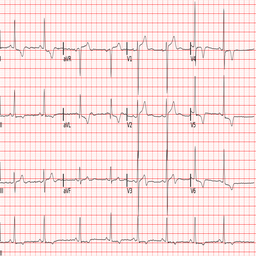

Imagem Transformada:


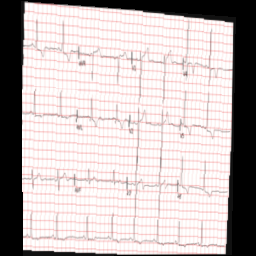

(3, 256, 256)
uint8
Imagem Original:


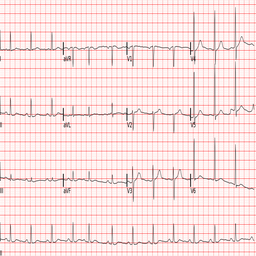

Imagem Transformada:


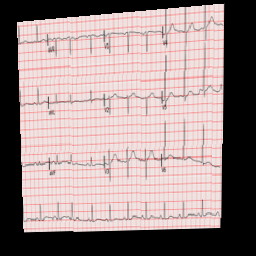

(3, 256, 256)
uint8
Imagem Original:


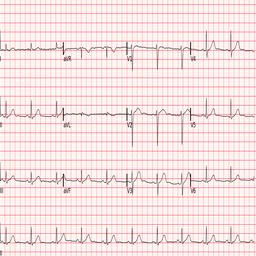

Imagem Transformada:


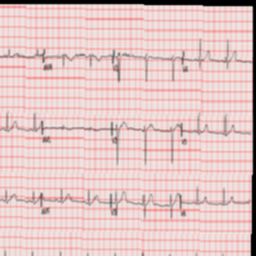

(3, 256, 256)
uint8
Imagem Original:


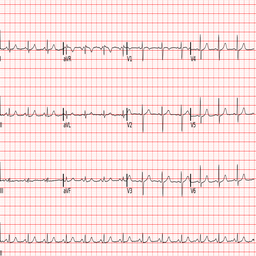

Imagem Transformada:


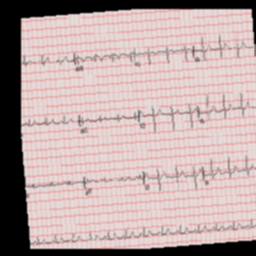

(3, 256, 256)
uint8
Imagem Original:


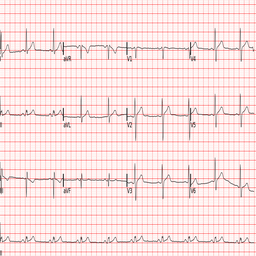

Imagem Transformada:


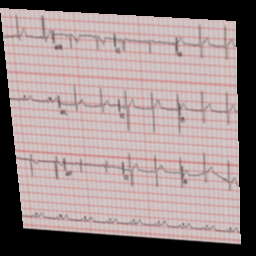

In [112]:
## crie uma transformacao de numpy para image pil e faca o display da imagem original e da imagem transformada para verificar se a transformacao esta correta
def numpy_to_pil(numpy_array):
    # Verifica se o array tem a forma correta (C, H, W)
   # if numpy_array.shape[0] != 3:
     #   raise ValueError("O array deve ter a forma (3, H, W) para ser convertido em imagem PIL.")

    print(numpy_array.shape)
    print(numpy_array.dtype)
    img_pil = Image.fromarray(numpy_array.transpose(1, 2, 0))  # Converte de (C, H, W) para (H, W, C)
    return (img_pil)

    return pil_image
for i in range(5):
    original_image = numpy_to_pil(img_dataset[i])
    transformed_image = get_transform(1)(Image.fromarray(img_dataset[i].transpose(1, 2, 0)))
    print("Imagem Original:")
    display(original_image)
    print("Imagem Transformada:")
    display(transformed_image)


## Target Label

In [113]:
data['NORMAL'] =data['NORMAL'].map({True: 1, False: 0})
data['Other'] = data['Other'].map({True: 1, False: 0})
data['AFIB'] = data['AFIB'].map({True: 1, False: 0})

In [114]:
## concat labels NORMAL_LABEL, RITM_NAO_AFIB, AFIB em uma coluna chamada rotulo
# NORMAL','Other','AFIB'
data['rotulo'] = data['NORMAL'].astype(str)   + data['Other'].astype(str) + data['AFIB'].astype(str)

In [115]:

data.query("rotulo == '000'")

,patient_id,path,age,sex,height,weight,AFIB,NORMAL,Other,rotulo


In [116]:
data['rotulo'].value_counts()

,count
rotulo,
100,808
010,143
001,49


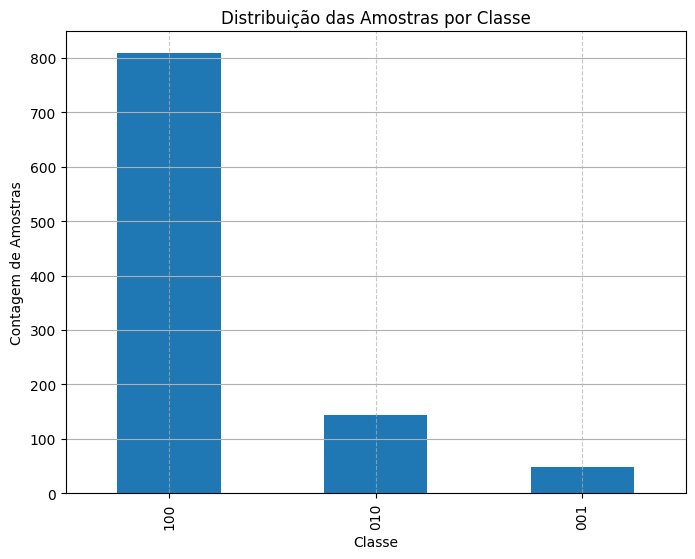

In [117]:
## Distribuicao das amostras
## Histograma da distribuicao das amostras
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
data['rotulo'].value_counts().plot(kind='bar')
plt.title('Distribuição das Amostras por Classe')
plt.xlabel('Classe')
plt.ylabel('Contagem de Amostras')
plt.grid(axis='y')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## Kfold

In [118]:
def a1():

    print(f"Configuracao do K-Fold para {folds} folds...")
    kf = KFold(n_splits=folds)
    kf.get_n_splits(tensor_imagem)
    print(kf)
    print("K-Fold configurado com sucesso.")

    print("Iniciando o treinamento com K-Fold Cross Validation...")

    train_loss_total = []
    val_loss_total =[]
    all_models =[]



## Class Weights

In [119]:
def class_weights(data_):
    """
    Calcula os pesos das classes com base na distribuição dos rótulos.

    Parâmetros:
        data_ (pd.DataFrame): DataFrame contendo a coluna 'rotulo'

    Retorna:
        torch.Tensor: Tensor contendo os pesos das classes
    """
    data_['class_weight'] = data_['rotulo'].map({'100':0,'010':1,'001':2})

    classes = ['NORMAL', 'Other', 'AFIB']
    y_train = data_['rotulo'].values
    # Conta quantas amostras existem por classe
    class_counts = np.bincount(data_['class_weight'], minlength=len(classes))

    # Evita divisão por zero
    class_counts = np.maximum(class_counts, 1)

    # Peso inverso da frequência
    class_weights = 1.0 / class_counts

    # Normaliza para não ficar exagerado
    class_weights = class_weights / class_weights.sum() * len(classes)

    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
    print(f"Pesos das classes: Para classe NORMAL: {class_weights_tensor[0]}")
    print(f"Pesos das classes: Para classe Other: {class_weights_tensor[1]}")
    print(f"Pesos das classes: Para classe AFIB: {class_weights_tensor[2]}")
    print(f"Pesos das classes: {class_weights_tensor}")
    if (len(class_weights_tensor) != 3):
        raise ValueError(f"Erro: Esperado 3 pesos de classe, mas obtido {len(class_weights_tensor)}. Verifique os rótulos no DataFrame.")
    return class_weights_tensor


## Split Dataset To Test / Valid and Train

In [120]:
## Split Dataframe in test e train

def split_dataframe(dataframe, test_size=0.2, random_state=42, fold=None):
    """
    Divide um DataFrame em conjuntos de treino e teste.

    Parâmetros:
        dataframe (pd.DataFrame): DataFrame a ser dividido
        test_size (float): Proporção do conjunto de teste (default: 0.2)
        random_state (int): Semente para reprodutibilidade (default: 42)
        fold (int): Número da dobra (default: None)

    Retorna:
        tuple: (train_df, test_df)
    """
    # Verificar se o DataFrame não está vazio
    if dataframe.empty:
        raise ValueError("O DataFrame fornecido está vazio.")

    # Embaralhar o DataFrame
    shuffled_df = dataframe.sample(frac=1, random_state=random_state).reset_index(drop=True)

    # Calcular o índice de corte
    split_index = int(len(shuffled_df) * (1 - test_size))

    # Dividir em treino e teste
    train_df = shuffled_df.iloc[:split_index].reset_index(drop=True)
    test_df = shuffled_df.iloc[split_index:].reset_index(drop=True)

    print(f"✓ DataFrame dividido com sucesso:")
    print(f"  Total de amostras: {len(dataframe)}")
    print(f"  Conjunto de treino e validação: {len(train_df)} amostras")
    print(f"  Conjunto de teste: {len(test_df)} amostras")
    # write test_df to csv in path_out/output/test_df.csv
    path_out = ""
    test_df.to_csv(os.path.join(path_out,OUTPUT_TEST_PATH, f'test_df_{fold}.csv'), index=False)
    print(f"  Conjunto de teste salvo em: {os.path.join(path_out, 'saidas/output', f'test_df_{fold}.csv')}")
    print('Analise estatistica do conjunto de teste:')
    print(test_df['rotulo'].value_counts())
    print('Analise estatistica do conjunto de treino:')
    print(train_df['rotulo'].value_counts())
    return train_df, test_df

## Train Valid Loop with DataAug

In [121]:
print('''
      ###############################################
      Inicio do treinamento com K-Fold Cross Validation
      ###############################################
      ''')
device = 'cuda:0'
train_loss_total = []
val_loss_total =[]
multiplier_dataaug = 3
patient_id_list = data['patient_id'][0:N_samples].unique()
kf = KFold(n_splits=folds)
for i, (train_index, test_index) in enumerate(kf.split(patient_id_list)):
    print(f"Fold {i}:")
    #print(f"  Train: index={train_index}")
    #print(f"  Test:  index={test_index}")
    ## init train test for folder
    ## Load images from train test kf

    print(f"\n{'#'*80}")
    print(f"train e val split para fold {len(train_index)}  e {len(test_index)}...")
    #print(f'amostras {train_index}')
    ## Obter os patient_id para treino e validação
    ## Load images from dados_train e dados_val

    train_patient_ids = data.iloc[train_index]
    train_patient_ids = train_patient_ids['patient_id']

    dados_train = data[data['patient_id'].isin(train_patient_ids)][0:N_samples]
    dados_train, _ = split_dataframe(dados_train, test_size=0.2, random_state=42, fold=i)
    print(f"\n{'#'*80}")


    # dados_train em dados_train e dados_test com 20% para testes

    print(f"\n{'#'*80}")

    img_dataset_train, data_imgs, error_count = validate_and_load_images(
        data=dados_train[['patient_id','path', 'AFIB']],  # Seleciona apenas as colunas necessárias
        image_path_prefix=path,  # path definido anteriormente
        n_samples=N_samples,  # Carrega todas as amostras do conjunto de treino
        max_errors=10,
        type_load_img = 3
    )


    # Aumenta a diversidade apenas no treino; mantenha augmentation conservadora para ECG.
    tensor_dataset_full_aug_train = data_augumentation(img_dataset_train, dados_train, size_aug=max(2, multiplier_dataaug), aug_version=3)
    ## Geracao do tensor de imagens

    print("Dataset de treino de dados (imagens + labels) criado com sucesso. Tamanho do Dataset:", len(tensor_dataset_full_aug_train))

    val_patient_ids = data.iloc[test_index]
    val_patient_ids = val_patient_ids['patient_id']

    dados_val = data[data['patient_id'].isin(val_patient_ids)][0:N_samples]
    print(path)
    img_dataset_val, data_imgs, error_count = validate_and_load_images(
        data=dados_val[['patient_id','path', 'AFIB']],  # Seleciona apenas as colunas necessárias
        image_path_prefix=path,  # path definido anteriormente
        n_samples=N_samples,
        max_errors=10,
        type_load_img = 3
    )
    tensor_dataset_valid = TensorDataset(torch.from_numpy(img_dataset_val), torch.from_numpy(np.array(dados_val[['NORMAL','Other','AFIB']].values, dtype=np.uint8)))
    #tensor_dataset_full_aug_val = data_augumentation(img_dataset_val, dados_val, 2)
    print("Dataset de validação de dados (imagens + labels) SEM DATAAUG criado com sucesso. Tamanho do Dataset:", len(img_dataset_val))

    ## Print com resumo dos dados utilizados para fold
    print(f"\n{'#'*80}")
    print(f"Resumo do Fold {i}:")
    print(f"  Tamanho do conjunto de treino: {len(tensor_dataset_full_aug_train)}")
    print(f"  Tamanho do conjunto de validação: {len(img_dataset_val)}")
    print(f"  Distribuição de labels no treino:\n{multiplier_dataaug*dados_train['rotulo'].value_counts()}")
    print(f"  Distribuição de labels na validação:\n{multiplier_dataaug*dados_val['rotulo'].value_counts()}")
    print(f"\n{'#'*80}")

    train_loader_img = DataLoader(tensor_dataset_full_aug_train, batch_size=BATCH_SIZE, shuffle=True)
    val_loader_img = DataLoader(tensor_dataset_valid, batch_size=BATCH_SIZE, shuffle=False)

    model= ECGClassifierResnet(num_classes=3)
    if (flg_salvar_modelos):
        salvar_model(model, path=OUTPUT_MODEL_PATH, name_file=f'model_fold_{i}.pth')
    print(f'Train and valid for Fold {i}')
    # Treina com Early Stopping (patience=5 épocas, delta=0.001)
    t, l,_,outputs,labels = simple_loop(model, train_loader_img, val_loader_img, epochs, batch_size=BATCH_SIZE, fold_index=i, patience=5, delta=0.0001, class_weights=class_weights(dados_train))
    ## Evaluate model.
    train_loss_total.append(t)
    val_loss_total.append(l)

print('''
      ###############################################
      Fim do treinamento com K-Fold Cross Validation
      ###############################################
      ''')
print("Treinamento com K-Fold Cross Validation concluído com sucesso.")


      ###############################################
      Inicio do treinamento com K-Fold Cross Validation
      ###############################################
      
Fold 0:

################################################################################
train e val split para fold 745  e 187...
✓ DataFrame dividido com sucesso:
  Total de amostras: 755
  Conjunto de treino e validação: 604 amostras
  Conjunto de teste: 151 amostras
  Conjunto de teste salvo em: saidas/output/test_df_0.csv
Analise estatistica do conjunto de teste:
rotulo
100    128
010     18
001      5
Name: count, dtype: int64
Analise estatistica do conjunto de treino:
rotulo
100    477
010     87
001     40
Name: count, dtype: int64

################################################################################

################################################################################

🖼️  VALIDAÇÃO E CARREGAMENTO DE IMAGENS

📌 Configuração:
  Amostras a processar: 604
  Prefixo de caminho: /content/

Carregando imagens: 100%|██████████| 604/604 [01:05<00:00,  9.15it/s]



✅ Carregamento concluído!
  Imagens carregadas com sucesso: 604
  Imagens com erro: 0
  Shape final: (604, 3, 256, 256)


Applying augmentation: 100%|██████████| 604/604 [00:12<00:00, 49.61it/s]


✓ Data augmentation completed for all images.
✓ Data augmentation aplicada. Novo shape do dataset: torch.Size([2416, 3, 256, 256]) no formato TensorDataset (imagens + labels)
Dataset de treino de dados (imagens + labels) criado com sucesso. Tamanho do Dataset: 2416
/content/content/drive/MyDrive/dataset_AFIB_Others/database_ptbxl/

🖼️  VALIDAÇÃO E CARREGAMENTO DE IMAGENS

📌 Configuração:
  Amostras a processar: 193
  Prefixo de caminho: /content/content/drive/MyDrive/dataset_AFIB_Others/database_ptbxl/
  Máximo de erros permitidos: 10

💾 Memória disponível: 46.79 GB
  Memória estimada para imagens: 0.04 GB

🔄 Carregando imagens...


...


Epoch 3/5
Train Loss: 0.342415 | Train Acc: 0.4253 | Train F1: 0.4968
Val Loss:   0.436234 | Val Acc: 0.3594 | Val F1: 0.4425 | Precision: 0.6081 | Recall: 0.3594
Train por classe:
  NORMAL: P=0.8897 | R=0.3956 | F1=0.5476
  Other: P=0.2619 | R=0.4221 | F1=0.3232
  AFIB: P=0.1130 | R=0.9076 | F1=0.2009
Val por classe:
  NORMAL: P=0.7386 | R=0.4194 | F1=0.5350
  Other: P=0.0769 | R=0.0417 | F1=0.0541
  AFIB: P=0.0330 | R=0.2308 | F1=0.0577



Validation loop: 100%|██████████| 4/4 [00:00<00:00,  4.98it/s]



Epoch 4/5
Train Loss: 0.288529 | Train Acc: 0.5764 | Train F1: 0.6226
Val Loss:   0.495624 | Val Acc: 0.2812 | Val F1: 0.3267 | Precision: 0.7117 | Recall: 0.2812
Train por classe:
  NORMAL: P=0.9020 | R=0.5494 | F1=0.6829
  Other: P=0.2685 | R=0.6106 | F1=0.3730
  AFIB: P=0.2655 | R=0.9068 | F1=0.4107
Val por classe:
  NORMAL: P=0.8571 | R=0.2323 | F1=0.3655
  Other: P=0.1298 | R=0.7083 | F1=0.2194
  AFIB: P=0.0526 | R=0.0769 | F1=0.0625



Validation loop: 100%|██████████| 4/4 [00:00<00:00,  5.02it/s]



Epoch 5/5
Train Loss: 0.238514 | Train Acc: 0.6807 | Train F1: 0.7141
Val Loss:   0.521597 | Val Acc: 0.6979 | Val F1: 0.6797 | Precision: 0.6639 | Recall: 0.6979
Train por classe:
  NORMAL: P=0.9563 | R=0.6352 | F1=0.7634
  Other: P=0.3465 | R=0.8187 | F1=0.4869
  AFIB: P=0.4307 | R=1.0000 | F1=0.6020
Val por classe:
  NORMAL: P=0.8049 | R=0.8516 | F1=0.8276
  Other: P=0.0769 | R=0.0417 | F1=0.0541
  AFIB: P=0.0667 | R=0.0769 | F1=0.0714

Salvado das metricas de validacao e treino
Pasta /content/drive/MyDrive/dataset_AFIB_Others/saida_1783713318/saidas//output/metricas/valid/fold_4 criada.
Metricas salvas em /content/drive/MyDrive/dataset_AFIB_Others/saida_1783713318/saidas//output/metricas/valid/fold_4 com os nomes predict_label_valid_fold_4.npy e true_label_valid_fold_4.npy e tamanhos (5, 3, 64) e (5, 3, 64)
Pasta /content/drive/MyDrive/dataset_AFIB_Others/saida_1783713318/saidas//output/metricas/train/fold_4 criada.
Metricas salvas em /content/drive/MyDrive/dataset_AFIB_Others/sai

In [122]:
import numpy as np

arr = np.random.rand(10, 2, 3, 3)

multiplicador = 2

novo_arr = np.repeat(arr, multiplicador, axis=0)

print(novo_arr.shape)
# (20, 2, 3, 3)

(20, 2, 3, 3)


In [123]:
path = 'dataset_AFIB_Others/data/'
STR_PATH = 'saida_123/saidas/'

## Avaliacao e Plots

In [124]:
def calc_metrics():
    ## Visao geral de todas as metricas juntas para cada fold com subplots
    N_fold = 5
    criterio = nn.CrossEntropyLoss()
    for i in range(N_fold):
        df1_pred = np.float32(np.load(f'{STR_PATH}/output/metricas/valid/fold_{i}/predict_label_valid_fold_{i}.npy', allow_pickle=True))
        df1_true = np.float32(np.load(f'{STR_PATH}/output/metricas/valid/fold_{i}/true_label_valid_fold_{i}.npy', allow_pickle=True))
        df1_pred_train = np.float32(np.load(f'{STR_PATH}/output/metricas/train/fold_{i}/predict_label_train_fold_{i}.npy', allow_pickle=True))
        df1_true_train = np.float32(np.load(f'{STR_PATH}/output/metricas/train/fold_{i}/true_label_train_fold_{i}.npy', allow_pickle=True))

        total_loss = []
        total_acc = []
        total_acc_train = []
        total_loss_train = []
        total_f1 = []
        total_f1_train = []
        total_recall = []
        total_recall_train = []
        total_precision = []
        total_precision_train = []
        for j in range(len(df1_pred)):
            outputs_tensor = torch.tensor(df1_pred[j]).to(torch.float)
            labels_tensor = torch.tensor(df1_true[j]).to(torch.float)

            accuracy = torch.sum(outputs_tensor == labels_tensor).item() / len(labels_tensor) / len(labels_tensor[-1])
            total_acc.append(accuracy)
            outputs_tensor_train = torch.tensor(df1_pred_train[j]).to(torch.float)
            labels_tensor_train = torch.tensor(df1_true_train[j]).to(torch.float)
            accuracy_train = torch.sum(outputs_tensor_train == labels_tensor_train).item() / len(labels_tensor_train) / len(labels_tensor_train[-1])
            total_acc_train.append(accuracy_train)

            ## Loss calculo
            loss = criterio(outputs_tensor, labels_tensor)/32
            total_loss.append(loss.item())
            loss_train = criterio(outputs_tensor_train, labels_tensor_train)/32
            total_loss_train.append(loss_train.item())

            ## Recall e f1 score calculo
            # Convert predictions to binary labels using a threshold of 0.5
            predicted_labels = outputs_tensor.argmax(dim=1).cpu().numpy()
            true_labels = labels_tensor.argmax(dim=1).cpu().numpy()
            precision = precision_score(true_labels, predicted_labels, average='weighted')
            total_precision.append(precision)
            precision_train = precision_score(labels_tensor_train.argmax(dim=1).cpu().numpy(), outputs_tensor_train.argmax(dim=1).cpu().numpy(), average='weighted')
            total_precision_train.append(precision_train)

            ## Recall train valid
            recall = recall_score(true_labels, predicted_labels, average='micro')
            total_recall.append(recall)
            recall_train = recall_score(labels_tensor_train.argmax(dim=1).cpu().numpy(), outputs_tensor_train.argmax(dim=1).cpu().numpy(), average='micro')
            total_recall_train.append(recall_train)

            ## F1 score train valid
            f1 = f1_score(true_labels, predicted_labels, average='micro')
            total_f1.append(f1)
            f1_train = f1_score(labels_tensor_train.argmax(dim=1).cpu().numpy(), outputs_tensor_train.argmax(dim=1).cpu().numpy(), average='micro')
            total_f1_train.append(f1_train)
        # Create subplots for loss and accuracy
        plt.figure(figsize=(30, 20))
        plt.subplot(3, 3, 1)
        plt.plot(total_loss, marker='o', linestyle='-', linewidth=2, label='Validation Loss')
        plt.plot(total_loss_train, marker='x', linestyle='--', linewidth=2, label='Train Loss')
        plt.title(f'Fold {i} - Train and Validation Loss over Batches')
        plt.xlabel('Batch Index')
        plt.ylabel('Loss')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.subplot(3, 3, 2)
        plt.plot(total_acc, marker='o', linestyle='-', linewidth=2, label='Validation Accuracy')
        plt.plot(total_acc_train, marker='x', linestyle='--', linewidth=2, label='Train Accuracy')
        plt.title(f'Fold {i} - Train and Validation Accuracy over Batches')
        plt.xlabel('Batch Index')
        plt.ylabel('Accuracy')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.subplot(3, 3, 3)
        plt.plot(total_f1, marker='o', linestyle='-', linewidth=2, label='Validation F1 Score')
        plt.plot(total_f1_train, marker='x', linestyle='--', linewidth=2, label='Train F1 Score')
        plt.title(f'Fold {i} - Train and Validation F1 Score over Batches')
        plt.xlabel('Batch Index')
        plt.ylabel('F1 Score')
        plt.grid(True, alpha=0.3)
        plt.legend()
        ## Add subplot for Precision and Recall
        plt.subplot(3, 3, 4)
        plt.plot(total_precision, marker='o', linestyle='-', linewidth=2, label='Validation Precision')
        plt.plot(total_precision_train, marker='x', linestyle='--', linewidth=2, label='Train Precision')

        plt.title(f'Fold {i} - Train and Validation Precision and Recall over Batches')
        plt.xlabel('Batch Index')
        plt.ylabel('Precision / Recall')
        plt.grid(True, alpha=0.3)
        plt.legend()

        ## Recall subplot
        plt.subplot(3, 3, 5)
        plt.plot(total_recall, marker='o', linestyle='-', linewidth=2, label='Validation Recall')
        plt.plot(total_recall_train, marker='x', linestyle='--', linewidth=2, label='Train Recall')
        plt.title(f'Fold {i} - Train    and Validation Recall over Batches')
        plt.xlabel('Batch Index')
        plt.ylabel('Recall')
        plt.grid(True, alpha=0.3)
        plt.legend()

        ## F1 Score subplot
        plt.subplot(3, 3, 6)
        plt.plot(total_f1, marker='o', linestyle='-', linewidth=2, label='Validation F1 Score')
        plt.plot(total_f1_train, marker='x', linestyle='--', linewidth=2, label='Train F1 Score')
        plt.title(f'Fold {i} - Train and Validation F1 Score over Batches')
        plt.xlabel('Batch Index')
        plt.ylabel('F1 Score')
        plt.grid(True, alpha=0.3)
        plt.legend()

        plt.show()

        print(f"Fold {i} - Mean Validation Loss: {np.mean(total_loss):.6f}, Std Validation Loss: {np.std(total_loss):.6f}")
        print(f"Fold {i} - Mean Train Loss: {np.mean(total_loss_train):.6f}, Std Train Loss: {np.std(total_loss_train):.6f}")
        print(f"Fold {i} - Mean Validation Accuracy: {np.mean(total_acc):.6f}, Std Validation Accuracy: {np.std(total_acc):.6f}")
        print(f"Fold {i} - Mean Train Accuracy: {np.mean(total_acc_train):.6f}, Std Train Accuracy: {np.std(total_acc_train):.6f}")
        print(f"Fold {i} - Mean Validation Precision: {np.mean(total_precision):.6f}, Std Validation Precision: {np.std(total_precision):.6f}")
        print(f"Fold {i} - Mean Train Precision: {np.mean(total_precision_train):.6f}, Std Train Precision: {np.std(total_precision_train):.6f}")
        print(f"Fold {i} - Mean Validation Recall: {np.mean(total_recall):.6f}, Std Validation Recall: {np.std(total_recall):.6f}")
        print(f"Fold {i} - Mean Train Recall: {np.mean(total_recall_train):.6f}, Std Train Recall: {np.std(total_recall_train):.6f}")
        print(f"Fold {i} - Mean Validation F1 Score: {np.mean(total_f1):.6f}, Std Validation F1 Score: {np.std(total_f1):.6f}")
        print(f"Fold {i} - Mean Train F1 Score: {np.mean(total_f1_train):.6f}, Std Train F1 Score: {np.std(total_f1_train):.6f}")

In [125]:
calc_metrics()

FileNotFoundError: [Errno 2] No such file or directory: 'saida_123/saidas//output/metricas/valid/fold_0/predict_label_valid_fold_0.npy'

In [ ]:
path = 'dataset_AFIB_Others/data/'
STR_PATH = 'saida_1234/saidas/'

In [ ]:
def calc_metrics():
    ## Visao geral de todas as metricas juntas para cada fold com subplots
    N_fold = 5
    criterio = nn.CrossEntropyLoss()
    for i in range(N_fold):
        df1_pred = np.float32(np.load(f'{STR_PATH}/output/metricas/valid/fold_{i}/predict_label_valid_fold_{i}.npy', allow_pickle=True))
        df1_true = np.float32(np.load(f'{STR_PATH}/output/metricas/valid/fold_{i}/true_label_valid_fold_{i}.npy', allow_pickle=True))
        df1_pred_train = np.float32(np.load(f'{STR_PATH}/output/metricas/train/fold_{i}/predict_label_train_fold_{i}.npy', allow_pickle=True))
        df1_true_train = np.float32(np.load(f'{STR_PATH}/output/metricas/train/fold_{i}/true_label_train_fold_{i}.npy', allow_pickle=True))

        total_loss = []
        total_acc = []
        total_acc_train = []
        total_loss_train = []
        total_f1 = []
        total_f1_train = []
        total_recall = []
        total_recall_train = []
        total_precision = []
        total_precision_train = []
        for j in range(len(df1_pred)):
            outputs_tensor = torch.tensor(df1_pred[j]).to(torch.float)
            labels_tensor = torch.tensor(df1_true[j]).to(torch.float)

            accuracy = torch.sum(outputs_tensor == labels_tensor).item() / len(labels_tensor) / len(labels_tensor[-1])
            total_acc.append(accuracy)
            outputs_tensor_train = torch.tensor(df1_pred_train[j]).to(torch.float)
            labels_tensor_train = torch.tensor(df1_true_train[j]).to(torch.float)
            accuracy_train = torch.sum(outputs_tensor_train == labels_tensor_train).item() / len(labels_tensor_train) / len(labels_tensor_train[-1])
            total_acc_train.append(accuracy_train)

            ## Loss calculo
            loss = criterio(outputs_tensor, labels_tensor)/32
            total_loss.append(loss.item())
            loss_train = criterio(outputs_tensor_train, labels_tensor_train)/32
            total_loss_train.append(loss_train.item())

            ## Recall e f1 score calculo
            # Convert predictions to binary labels using a threshold of 0.5
            predicted_labels = outputs_tensor.argmax(dim=1).cpu().numpy()
            true_labels = labels_tensor.argmax(dim=1).cpu().numpy()
            precision = precision_score(true_labels, predicted_labels, average='weighted')
            total_precision.append(precision)
            precision_train = precision_score(labels_tensor_train.argmax(dim=1).cpu().numpy(), outputs_tensor_train.argmax(dim=1).cpu().numpy(), average='weighted')
            total_precision_train.append(precision_train)

            ## Recall train valid
            recall = recall_score(true_labels, predicted_labels, average='micro')
            total_recall.append(recall)
            recall_train = recall_score(labels_tensor_train.argmax(dim=1).cpu().numpy(), outputs_tensor_train.argmax(dim=1).cpu().numpy(), average='micro')
            total_recall_train.append(recall_train)

            ## F1 score train valid
            f1 = f1_score(true_labels, predicted_labels, average='micro')
            total_f1.append(f1)
            f1_train = f1_score(labels_tensor_train.argmax(dim=1).cpu().numpy(), outputs_tensor_train.argmax(dim=1).cpu().numpy(), average='micro')
            total_f1_train.append(f1_train)
        # Create subplots for loss and accuracy
        plt.figure(figsize=(30, 20))
        plt.subplot(3, 3, 1)
        plt.plot(total_loss, marker='o', linestyle='-', linewidth=2, label='Validation Loss')
        plt.plot(total_loss_train, marker='x', linestyle='--', linewidth=2, label='Train Loss')
        plt.title(f'Fold {i} - Train and Validation Loss over Batches')
        plt.xlabel('Batch Index')
        plt.ylabel('Loss')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.subplot(3, 3, 2)
        plt.plot(total_acc, marker='o', linestyle='-', linewidth=2, label='Validation Accuracy')
        plt.plot(total_acc_train, marker='x', linestyle='--', linewidth=2, label='Train Accuracy')
        plt.title(f'Fold {i} - Train and Validation Accuracy over Batches')
        plt.xlabel('Batch Index')
        plt.ylabel('Accuracy')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.subplot(3, 3, 3)
        plt.plot(total_f1, marker='o', linestyle='-', linewidth=2, label='Validation F1 Score')
        plt.plot(total_f1_train, marker='x', linestyle='--', linewidth=2, label='Train F1 Score')
        plt.title(f'Fold {i} - Train and Validation F1 Score over Batches')
        plt.xlabel('Batch Index')
        plt.ylabel('F1 Score')
        plt.grid(True, alpha=0.3)
        plt.legend()
        ## Add subplot for Precision and Recall
        plt.subplot(3, 3, 4)
        plt.plot(total_precision, marker='o', linestyle='-', linewidth=2, label='Validation Precision')
        plt.plot(total_precision_train, marker='x', linestyle='--', linewidth=2, label='Train Precision')

        plt.title(f'Fold {i} - Train and Validation Precision and Recall over Batches')
        plt.xlabel('Batch Index')
        plt.ylabel('Precision / Recall')
        plt.grid(True, alpha=0.3)
        plt.legend()

        ## Recall subplot
        plt.subplot(3, 3, 5)
        plt.plot(total_recall, marker='o', linestyle='-', linewidth=2, label='Validation Recall')
        plt.plot(total_recall_train, marker='x', linestyle='--', linewidth=2, label='Train Recall')
        plt.title(f'Fold {i} - Train    and Validation Recall over Batches')
        plt.xlabel('Batch Index')
        plt.ylabel('Recall')
        plt.grid(True, alpha=0.3)
        plt.legend()

        ## F1 Score subplot
        plt.subplot(3, 3, 6)
        plt.plot(total_f1, marker='o', linestyle='-', linewidth=2, label='Validation F1 Score')
        plt.plot(total_f1_train, marker='x', linestyle='--', linewidth=2, label='Train F1 Score')
        plt.title(f'Fold {i} - Train and Validation F1 Score over Batches')
        plt.xlabel('Batch Index')
        plt.ylabel('F1 Score')
        plt.grid(True, alpha=0.3)
        plt.legend()

        plt.show()

        print(f"Fold {i} - Mean Validation Loss: {np.mean(total_loss):.6f}, Std Validation Loss: {np.std(total_loss):.6f}")
        print(f"Fold {i} - Mean Train Loss: {np.mean(total_loss_train):.6f}, Std Train Loss: {np.std(total_loss_train):.6f}")
        print(f"Fold {i} - Mean Validation Accuracy: {np.mean(total_acc):.6f}, Std Validation Accuracy: {np.std(total_acc):.6f}")
        print(f"Fold {i} - Mean Train Accuracy: {np.mean(total_acc_train):.6f}, Std Train Accuracy: {np.std(total_acc_train):.6f}")
        print(f"Fold {i} - Mean Validation Precision: {np.mean(total_precision):.6f}, Std Validation Precision: {np.std(total_precision):.6f}")
        print(f"Fold {i} - Mean Train Precision: {np.mean(total_precision_train):.6f}, Std Train Precision: {np.std(total_precision_train):.6f}")
        print(f"Fold {i} - Mean Validation Recall: {np.mean(total_recall):.6f}, Std Validation Recall: {np.std(total_recall):.6f}")
        print(f"Fold {i} - Mean Train Recall: {np.mean(total_recall_train):.6f}, Std Train Recall: {np.std(total_recall_train):.6f}")
        print(f"Fold {i} - Mean Validation F1 Score: {np.mean(total_f1):.6f}, Std Validation F1 Score: {np.std(total_f1):.6f}")
        print(f"Fold {i} - Mean Train F1 Score: {np.mean(total_f1_train):.6f}, Std Train F1 Score: {np.std(total_f1_train):.6f}")

In [ ]:
calc_metrics()

FileNotFoundError: [Errno 2] No such file or directory: 'saida_1234/saidas//output/metricas/valid/fold_0/predict_label_valid_fold_0.npy'